In [1]:
import matplotlib.pyplot as plt
import numpy as np
import mplhep as hep
import pickle as pkl
import os 
import sys
os.chdir('/home/aritra/ws/unfold')
sys.path.insert(0, "./src")
from unfold.tools import binning
from unfold.utils.integrate_and_rebin import rebin_hist
hep.style.use("CMS")
#dpi = 50
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 100

In [2]:
with open("inputs/rho/backgrounds_all.pkl", "rb") as f:
    bkg = pkl.load(f)
with open("inputs/rho/st_all.pkl", "rb") as f:
    st = pkl.load(f)



In [3]:
bins_g = binning.bin_edges(groomed = True)
bins_u = binning.bin_edges(groomed = False)

rho_edges_g = bins_g.reco_rho_edges_by_pt[0]
rho_edges_u = bins_u.reco_rho_edges_by_pt[0]

In [4]:
def compute_total_unc(pythia_hist):
    # era = "2016APV"
    # with open(f"inputs/rho/jms_pythia_{era}_syst.pkl", "rb") as f:
    #     pythia = pkl.load(f)
    # pythia_hist = pythia[ 'ptjet_rhojet_u_reco'].project("dataset",  "mpt_reco", "systematic")
    syst_list = pythia_hist.axes["systematic"]

    up = 0
    down = 0
    for syst in syst_list:
        if syst.endswith("Down"):
            down += np.abs(pythia_hist[sum, :, "nominal"].values() - pythia_hist[sum, :, syst].values())**2
        elif syst.endswith("Up"):
            up += np.abs(pythia_hist[sum, :, "nominal"].values() - pythia_hist[sum, :, syst].values())**2
    up += pythia_hist[sum, :, "nominal"].variances()
    down += pythia_hist[sum, :, "nominal"].variances()
    up = np.sqrt(up)
    down = np.sqrt(down)

    return up, down



/home/aritra/ws/unfold/src/unfold/utils/integrate_and_rebin.py:21: FutureWarning: Accessing storage type has changed from _storage_type to storage_type, and will be removed in future.
  hnew = hist.Hist(*axes, name=h.name, storage=h._storage_type())
/home/aritra/ws/unfold/src/unfold/utils/integrate_and_rebin.py:42: FutureWarning: Accessing storage type has changed from _storage_type to storage_type, and will be removed in future.
  if hnew._storage_type() == hist.storage.Weight():


pythia sum: 25300.781036914585
scale: 2.1307968452395327


/tmp/ipykernel_27122/899919057.py:68: RuntimeWarning: invalid value encountered in divide
  ratio = data.values()/(pythia.values() + ww.values() + wz.values() + zz.values() + ttjets.values() + st.values())
/tmp/ipykernel_27122/899919057.py:69: RuntimeWarning: invalid value encountered in divide
  ratio_err = np.sqrt(data.values())/(pythia.values() + ww.values() + wz.values() + zz.values() + ttjets.values() + st.values())
/tmp/ipykernel_27122/899919057.py:72: RuntimeWarning: divide by zero encountered in divide
  print("1+up/total_mc:", 1+ (up/total_mc))
/tmp/ipykernel_27122/899919057.py:73: RuntimeWarning: divide by zero encountered in divide
  print("1-down/total_mc:", 1- (down/total_mc))
/tmp/ipykernel_27122/899919057.py:73: RuntimeWarning: invalid value encountered in divide
  print("1-down/total_mc:", 1- (down/total_mc))
/tmp/ipykernel_27122/899919057.py:74: RuntimeWarning: divide by zero encountered in divide
  plt.stairs(1 + np.where(total_mc!=0, up/total_mc, 0), baseline=1 - np.

1+up/total_mc: [          inf           inf    3.61958739   17.02351085 1024.69816471
    4.00479025    9.14937332    7.00236688    3.5454105     2.80035128
    1.74802144    1.27260004    1.10326717    1.09530649    1.09718856
    1.08735827    1.08980095    1.10616907    1.27523489           inf]
1-down/total_mc: [        nan         nan -0.41908818 -0.4228948  -0.01489526 -0.21179969
 -0.06410835  0.17174255  0.2305563   0.45148292  0.57257813  0.76365826
  0.88829934  0.92048325  0.91062899  0.92029119  0.91965254  0.90385333
  0.79231379        -inf]


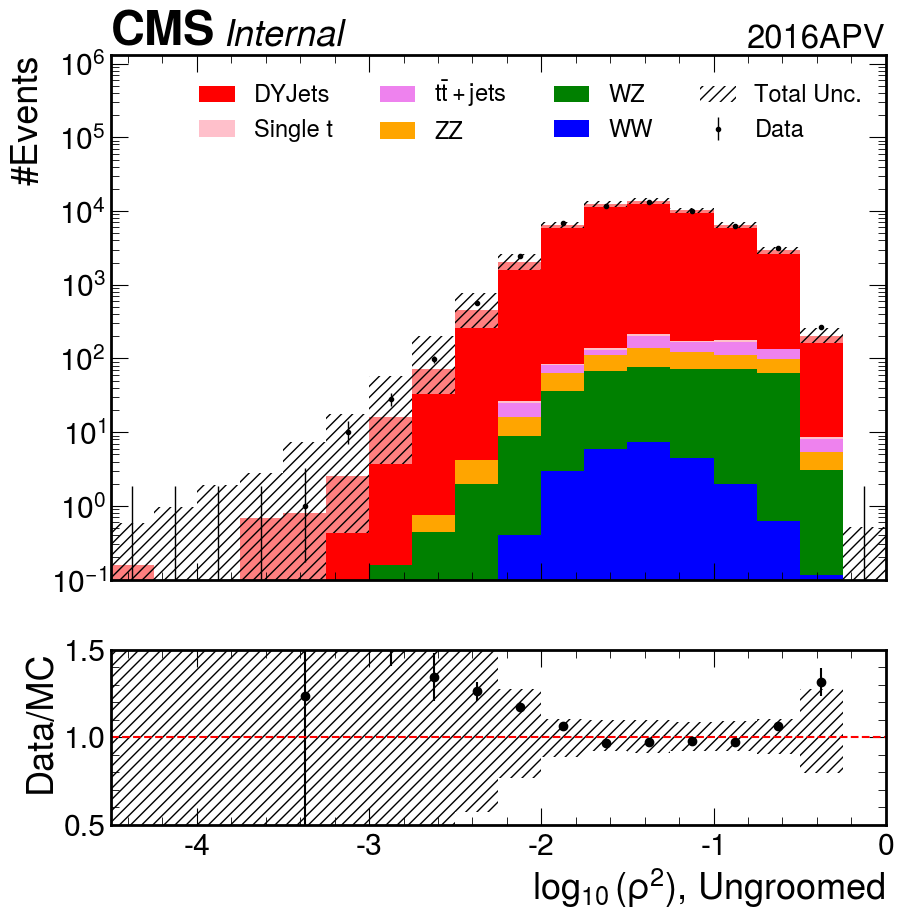

In [5]:
#2016



def plot_data_mc( bkg, st, hist, field, era, file_id = "",xmin = -4.5, groomed = True):

    with open(f"inputs/rho/jms_pythia_{era}_syst.pkl", "rb") as f:
        pythia = pkl.load(f)
    with open(f"inputs/rho/rho_data_{era}.pkl", "rb") as f:
        data = pkl.load(f)
    
    era_dic = {"2016": "UL16NanoAODv9", "2017": "UL17NanoAODv9", "2018": "UL18NanoAODv9", "2016APV": "UL16NanoAODAPVv9" }
    bkg = bkg[hist].project("dataset", field)
    st_hist = st[hist].project("dataset", field)
    pythia_hist_syst = pythia[hist].project("dataset",  field, "systematic")
    data_hist = data[hist].project("dataset", field)

    

    data = data_hist.project(field)
    pythia = pythia_hist_syst["pythia_"+era_dic[era], :, "nominal"]
    

    ww = bkg["ww_"+era_dic[era], :]
    wz = bkg["wz_"+era_dic[era], :]
    zz = bkg["zz_"+era_dic[era], :]
    ttjets = bkg["ttjets_"+era_dic[era], :]
    st = st_hist["ST_"+era_dic[era], :]
    
    samples = [ww, wz, zz, ttjets, st, pythia, data, pythia_hist_syst]
    samples = [rebin_hist(h, field, rho_edges_g) for h in samples]
    ww, wz, zz, ttjets, st, pythia, data, pythia_hist_syst = samples

    up, down = compute_total_unc(pythia_hist_syst)
    print("pythia sum:", pythia.sum().value)
    scale = data.sum().value/ (pythia.sum().value + ww.sum().value + wz.sum().value + zz.sum().value + ttjets.sum().value + st.sum().value)
    print("scale:", scale)

    ww = ww*scale
    wz = wz*scale
    zz = zz*scale
    ttjets = ttjets*scale
    st = st*scale
    pythia = pythia*scale
    up = up*scale
    down = down*scale
    #setup ratio plot
    fig, (ax, rax) = plt.subplots(2, 1, sharex=True, gridspec_kw={"height_ratios": (3, 1)})
    plt.sca(ax)
    
    hep.histplot([ww, wz, zz, ttjets, st, pythia], label=["WW", "WZ", "ZZ", r"$t\bar{t}+\text{jets}$", "Single t", "DYJets"], color = ["blue", "green", "orange", 'violet', "pink", "red"] ,stack=True, histtype = "fill")
    total_mc = (pythia.values() + ww.values() + wz.values() + zz.values() + ttjets.values() + st.values())
    

    hep.histplot(data, label="Data", histtype="errorbar", color="black")
    plt.stairs(total_mc + up, baseline=total_mc - down, edges=pythia.axes[0].edges, label="Total Unc.", hatch = "///", color = 'white',  fill=True, alpha=0.5)
    
    plt.xlim(xmin, 0)
    plt.ylim(0.1, data.values().max()*100)
    plt.legend(ncol = 4, fontsize = 17)
    plt.yscale("log")
    plt.xlabel("")
    plt.ylabel("#Events")
    hep.cms.label("Internal", data=True, rlabel = era)


    plt.sca(rax)
    ratio = data.values()/(pythia.values() + ww.values() + wz.values() + zz.values() + ttjets.values() + st.values())
    ratio_err = np.sqrt(data.values())/(pythia.values() + ww.values() + wz.values() + zz.values() + ttjets.values() + st.values())
    plt.errorbar(data.axes[0].centers, ratio, yerr=ratio_err, fmt="o", color="black")
    plt.axhline(1, color="red", linestyle="--")
    print("1+up/total_mc:", 1+ (up/total_mc))
    print("1-down/total_mc:", 1- (down/total_mc))
    plt.stairs(1 + np.where(total_mc!=0, up/total_mc, 0), baseline=1 - np.where(total_mc!=0, down/total_mc, 0), edges=pythia.axes[0].edges, label="Total Unc.", hatch = "///", color = 'white',  fill=True, alpha=0.0)
    plt.xlim(xmin, 0)
    plt.ylim(0.5, 1.5)
    plt.xlabel(r"$\log_{10}(\rho^2)$, Groomed" if groomed else r"$\log_{10}(\rho^2)$, Ungroomed")
    plt.ylabel("Data/MC")
    plt.savefig(f"outputs/rho/data_mc/data_mc_{file_id}_{era}.pdf")
plot_data_mc( bkg, st, "ptjet_rhojet_u_reco", "mpt_reco", "2016APV", file_id = "rho_u", groomed = False )

/home/aritra/ws/unfold/src/unfold/utils/integrate_and_rebin.py:21: FutureWarning: Accessing storage type has changed from _storage_type to storage_type, and will be removed in future.
  hnew = hist.Hist(*axes, name=h.name, storage=h._storage_type())
/home/aritra/ws/unfold/src/unfold/utils/integrate_and_rebin.py:42: FutureWarning: Accessing storage type has changed from _storage_type to storage_type, and will be removed in future.
  if hnew._storage_type() == hist.storage.Weight():


pythia sum: 31822.168826442292
scale: 1.515393630968604
1+up/total_mc: [1.12531199 1.1179301  1.10988167 1.10068782 1.08975983 1.08567576
 1.08508377 1.08661527 1.08475845 1.08299043 1.08261162 1.08397566
 1.08515145 1.08447769 1.08614663 1.08787432 1.09090738 1.10541148
 1.28715334 1.22850046]
1-down/total_mc: [0.90241358 0.90588141 0.90409248 0.91187156 0.91922457 0.92215295
 0.92423119 0.91931697 0.92603306 0.92413846 0.9251966  0.9250349
 0.9240564  0.92465314 0.92226121 0.92337154 0.92006792 0.90557696
 0.77695449 0.82459602]


/home/aritra/ws/unfold/src/unfold/utils/integrate_and_rebin.py:21: FutureWarning: Accessing storage type has changed from _storage_type to storage_type, and will be removed in future.
  hnew = hist.Hist(*axes, name=h.name, storage=h._storage_type())
/home/aritra/ws/unfold/src/unfold/utils/integrate_and_rebin.py:42: FutureWarning: Accessing storage type has changed from _storage_type to storage_type, and will be removed in future.
  if hnew._storage_type() == hist.storage.Weight():


pythia sum: 25172.34418133867
scale: 2.129896178177322
1+up/total_mc: [1.1254963  1.14656055 1.10634657 1.10364264 1.09429638 1.08681071
 1.086726   1.08891995 1.08787175 1.08604188 1.08563516 1.08393445
 1.08562061 1.08576421 1.08573826 1.08840351 1.09237255 1.10542072
 1.2915531  1.42816695]
1-down/total_mc: [0.90341858 0.8984488  0.90242954 0.90932025 0.91441625 0.92227895
 0.92328952 0.92357397 0.91938699 0.92295882 0.9246557  0.92338181
 0.9242226  0.92385391 0.92341002 0.92110174 0.91908931 0.90530305
 0.77798815 0.81609746]


/home/aritra/ws/unfold/src/unfold/utils/integrate_and_rebin.py:21: FutureWarning: Accessing storage type has changed from _storage_type to storage_type, and will be removed in future.
  hnew = hist.Hist(*axes, name=h.name, storage=h._storage_type())
/home/aritra/ws/unfold/src/unfold/utils/integrate_and_rebin.py:42: FutureWarning: Accessing storage type has changed from _storage_type to storage_type, and will be removed in future.
  if hnew._storage_type() == hist.storage.Weight():


pythia sum: 66825.02065523065
scale: 1.8589093905905836
1+up/total_mc: [1.09789022 1.09832926 1.09304838 1.08993843 1.08719801 1.0848912
 1.08311455 1.08183311 1.08025938 1.08105301 1.08137812 1.08215348
 1.08291344 1.08398459 1.08384764 1.08638115 1.0891985  1.10132532
 1.14434027 1.17270399]
1-down/total_mc: [0.91456644 0.91317199 0.91825786 0.92012365 0.92307369 0.92446052
 0.92583159 0.92650423 0.92800752 0.927401   0.92737754 0.92678343
 0.92630842 0.92526713 0.92585477 0.92355973 0.92189188 0.90868413
 0.83235214 0.85545827]


/home/aritra/ws/unfold/src/unfold/utils/integrate_and_rebin.py:21: FutureWarning: Accessing storage type has changed from _storage_type to storage_type, and will be removed in future.
  hnew = hist.Hist(*axes, name=h.name, storage=h._storage_type())
/home/aritra/ws/unfold/src/unfold/utils/integrate_and_rebin.py:42: FutureWarning: Accessing storage type has changed from _storage_type to storage_type, and will be removed in future.
  if hnew._storage_type() == hist.storage.Weight():


pythia sum: 99208.27051861485
scale: 1.8785580318629453
1+up/total_mc: [1.09854246 1.09752972 1.09381886 1.09095396 1.08796521 1.08523418
 1.08337844 1.08229577 1.08120551 1.08218518 1.08310948 1.082913
 1.08384519 1.08484822 1.08629834 1.08777767 1.08955492 1.09924068
 1.13840495 1.15157599]
1-down/total_mc: [0.91446734 0.91389248 0.91753748 0.91992016 0.92221485 0.92435981
 0.92559545 0.92649672 0.92724253 0.92661352 0.92604533 0.92633891
 0.92561898 0.92469678 0.92377259 0.92263218 0.92160466 0.91333935
 0.87346925 0.85141342]


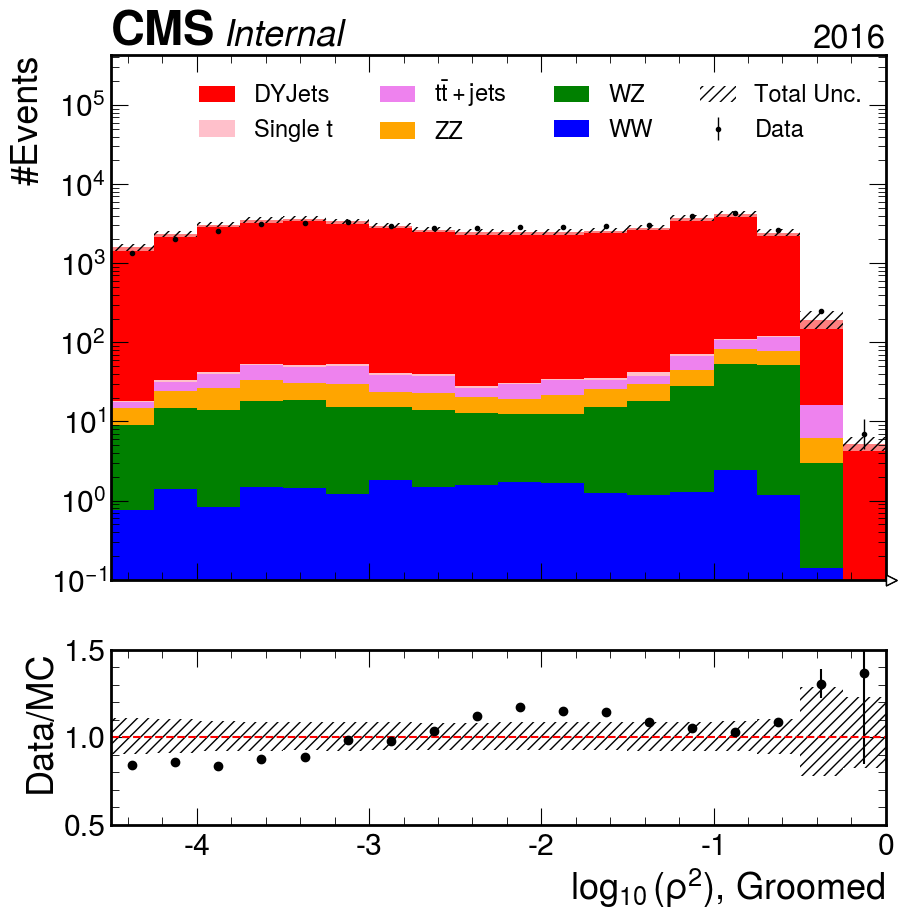

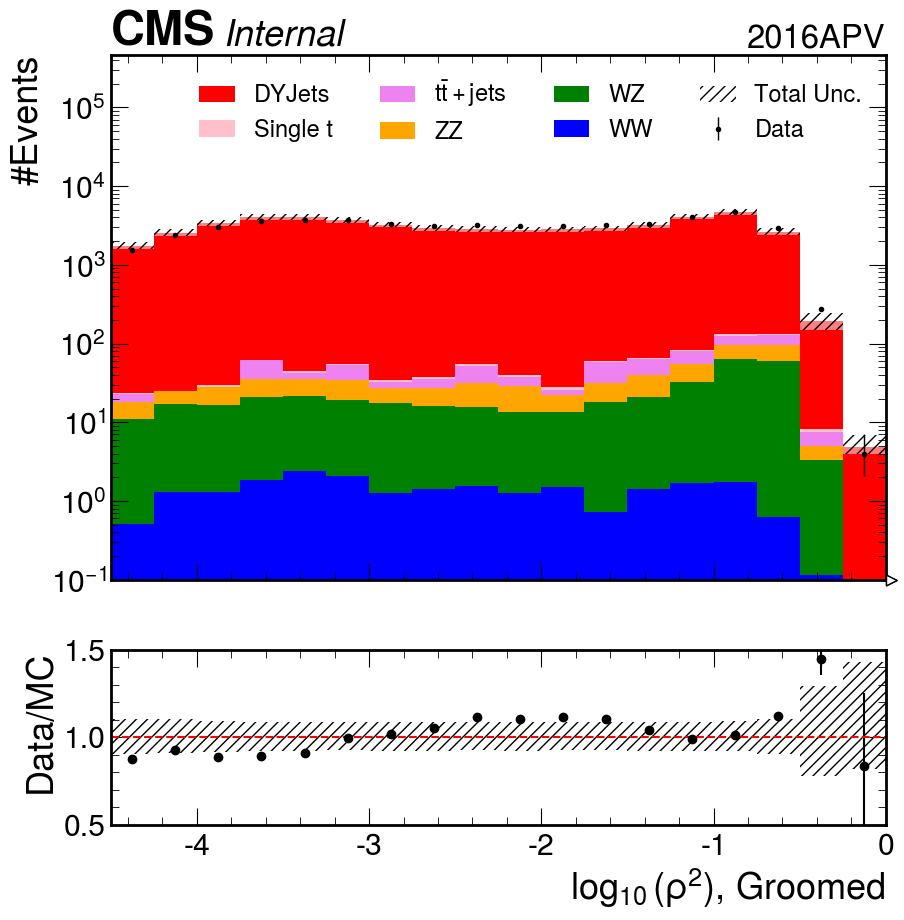

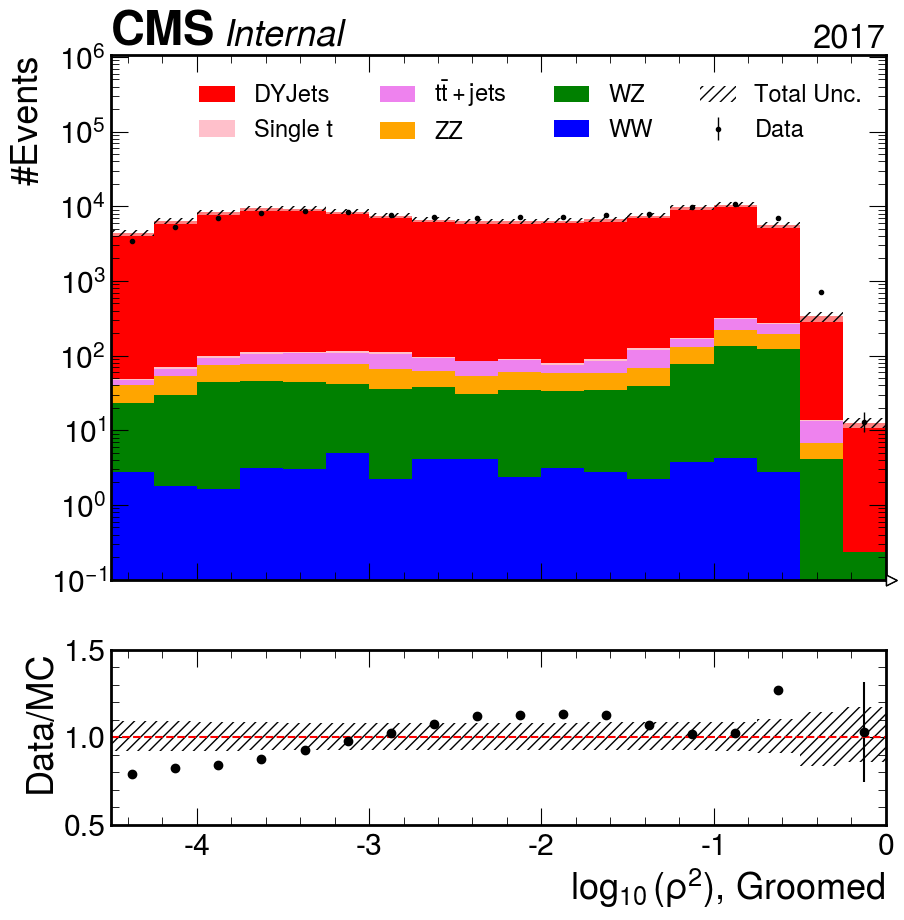

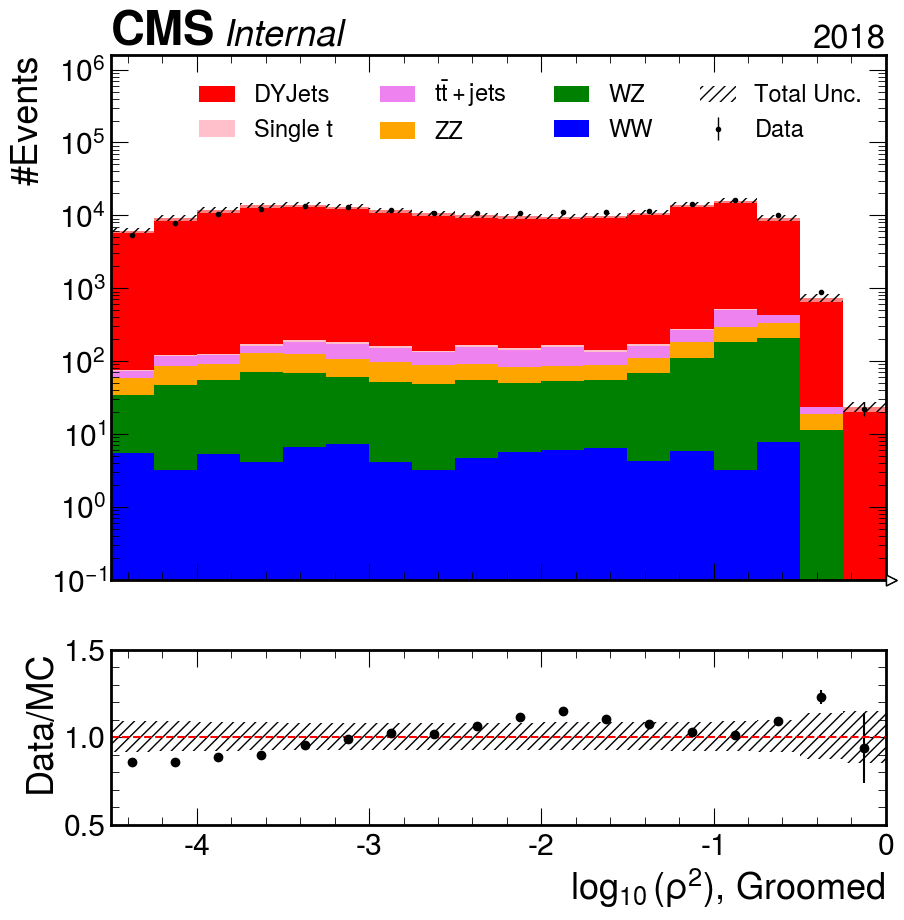

In [6]:
for era in ["2016","2016APV", "2017", "2018"]:
    plot_data_mc( bkg, st, "ptjet_rhojet_g_reco", "mpt_reco", era, file_id = "rho_g", groomed = True )

/home/aritra/ws/unfold/src/unfold/utils/integrate_and_rebin.py:21: FutureWarning: Accessing storage type has changed from _storage_type to storage_type, and will be removed in future.
  hnew = hist.Hist(*axes, name=h.name, storage=h._storage_type())
/home/aritra/ws/unfold/src/unfold/utils/integrate_and_rebin.py:42: FutureWarning: Accessing storage type has changed from _storage_type to storage_type, and will be removed in future.
  if hnew._storage_type() == hist.storage.Weight():


pythia sum: 31975.046364557656
scale: 1.516242735001118


/tmp/ipykernel_12138/899919057.py:68: RuntimeWarning: invalid value encountered in divide
  ratio = data.values()/(pythia.values() + ww.values() + wz.values() + zz.values() + ttjets.values() + st.values())
/tmp/ipykernel_12138/899919057.py:69: RuntimeWarning: invalid value encountered in divide
  ratio_err = np.sqrt(data.values())/(pythia.values() + ww.values() + wz.values() + zz.values() + ttjets.values() + st.values())
/tmp/ipykernel_12138/899919057.py:72: RuntimeWarning: divide by zero encountered in divide
  print("1+up/total_mc:", 1+ (up/total_mc))
/tmp/ipykernel_12138/899919057.py:73: RuntimeWarning: invalid value encountered in divide
  print("1-down/total_mc:", 1- (down/total_mc))
/tmp/ipykernel_12138/899919057.py:74: RuntimeWarning: divide by zero encountered in divide
  plt.stairs(1 + np.where(total_mc!=0, up/total_mc, 0), baseline=1 - np.where(total_mc!=0, down/total_mc, 0), edges=pythia.axes[0].edges, label="Total Unc.", hatch = "///", color = 'white',  fill=True, alpha=0.0

1+up/total_mc: [        inf         inf         inf         inf         inf  5.50862314
 12.56272305  4.59190955  3.68142607  2.58418929  1.67173382  1.29098988
  1.1035465   1.09591231  1.09400322  1.0851928   1.08881003  1.1042534
  1.29513429         inf]
1-down/total_mc: [        nan         nan         nan         nan         nan -0.28074662
 -0.18478001  0.13301714  0.18435939  0.50901482  0.61066328  0.76342688
  0.88627666  0.91937051  0.91369858  0.92230068  0.92058314  0.90695317
  0.81081251         nan]


/home/aritra/ws/unfold/src/unfold/utils/integrate_and_rebin.py:21: FutureWarning: Accessing storage type has changed from _storage_type to storage_type, and will be removed in future.
  hnew = hist.Hist(*axes, name=h.name, storage=h._storage_type())
/home/aritra/ws/unfold/src/unfold/utils/integrate_and_rebin.py:42: FutureWarning: Accessing storage type has changed from _storage_type to storage_type, and will be removed in future.
  if hnew._storage_type() == hist.storage.Weight():


...

pythia sum: 67143.80657945073
scale: 1.8583776338618792


/tmp/ipykernel_12138/899919057.py:68: RuntimeWarning: invalid value encountered in divide
  ratio = data.values()/(pythia.values() + ww.values() + wz.values() + zz.values() + ttjets.values() + st.values())
/tmp/ipykernel_12138/899919057.py:69: RuntimeWarning: invalid value encountered in divide
  ratio_err = np.sqrt(data.values())/(pythia.values() + ww.values() + wz.values() + zz.values() + ttjets.values() + st.values())
/tmp/ipykernel_12138/899919057.py:72: RuntimeWarning: divide by zero encountered in divide
  print("1+up/total_mc:", 1+ (up/total_mc))
/tmp/ipykernel_12138/899919057.py:72: RuntimeWarning: invalid value encountered in divide
  print("1+up/total_mc:", 1+ (up/total_mc))
/tmp/ipykernel_12138/899919057.py:73: RuntimeWarning: divide by zero encountered in divide
  print("1-down/total_mc:", 1- (down/total_mc))
/tmp/ipykernel_12138/899919057.py:73: RuntimeWarning: invalid value encountered in divide
  print("1-down/total_mc:", 1- (down/total_mc))
/tmp/ipykernel_12138/89991905

1+up/total_mc: [       inf        nan 2.91242048 3.21821554 3.99806959 1.51275788
 1.53036456 1.48848695 1.5296304  1.25965538 1.17782692 1.11191107
 1.09056965 1.08591193 1.08269533 1.08255421 1.08627412 1.09823323
 1.14914595        nan]
1-down/total_mc: [       -inf         nan -0.42355938 -0.2764977   0.40226525  0.23421887
  0.56948143  0.46196988  0.77861941  0.75550569  0.8455895   0.89870708
  0.91945379  0.92361665  0.92619224  0.92648375  0.92386344  0.91447004
  0.87491591         nan]


/home/aritra/ws/unfold/src/unfold/utils/integrate_and_rebin.py:21: FutureWarning: Accessing storage type has changed from _storage_type to storage_type, and will be removed in future.
  hnew = hist.Hist(*axes, name=h.name, storage=h._storage_type())
/home/aritra/ws/unfold/src/unfold/utils/integrate_and_rebin.py:42: FutureWarning: Accessing storage type has changed from _storage_type to storage_type, and will be removed in future.
  if hnew._storage_type() == hist.storage.Weight():


pythia sum: 99684.88362159484
scale: 1.8791609532383582
1+up/total_mc: [1.85788178 2.03958743 5.92315333 1.96372197 2.39751399 2.97496683
 1.22903971 1.50769948 1.25596115 1.20397428 1.13710444 1.103996
 1.09122604 1.08634794 1.08274511 1.08354133 1.0872236  1.09642908
 1.11776916 1.45675304]
1-down/total_mc: [-0.29936068 -0.02800056 -2.19352201  0.00296884 -0.61325369  0.500184
  0.50720205  0.76948375  0.77200663  0.83975325  0.86640199  0.90873763
  0.91921237  0.92345521  0.92624894  0.92588442  0.92329725  0.91663086
  0.89777908  0.23395122]


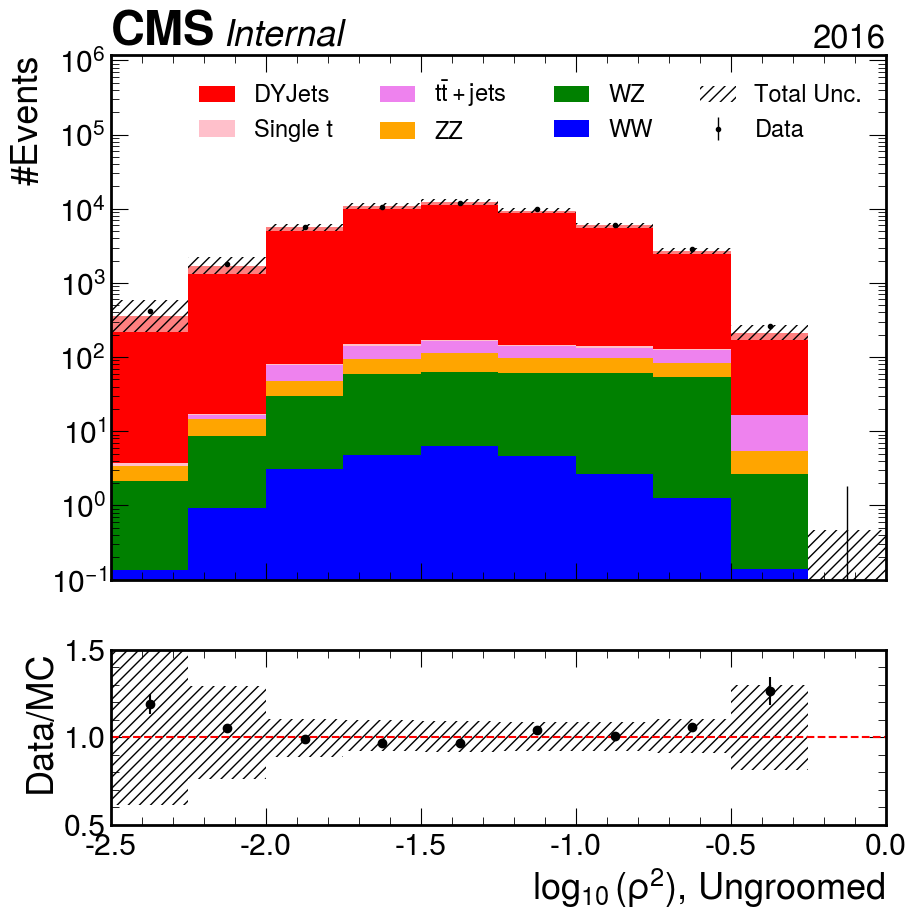

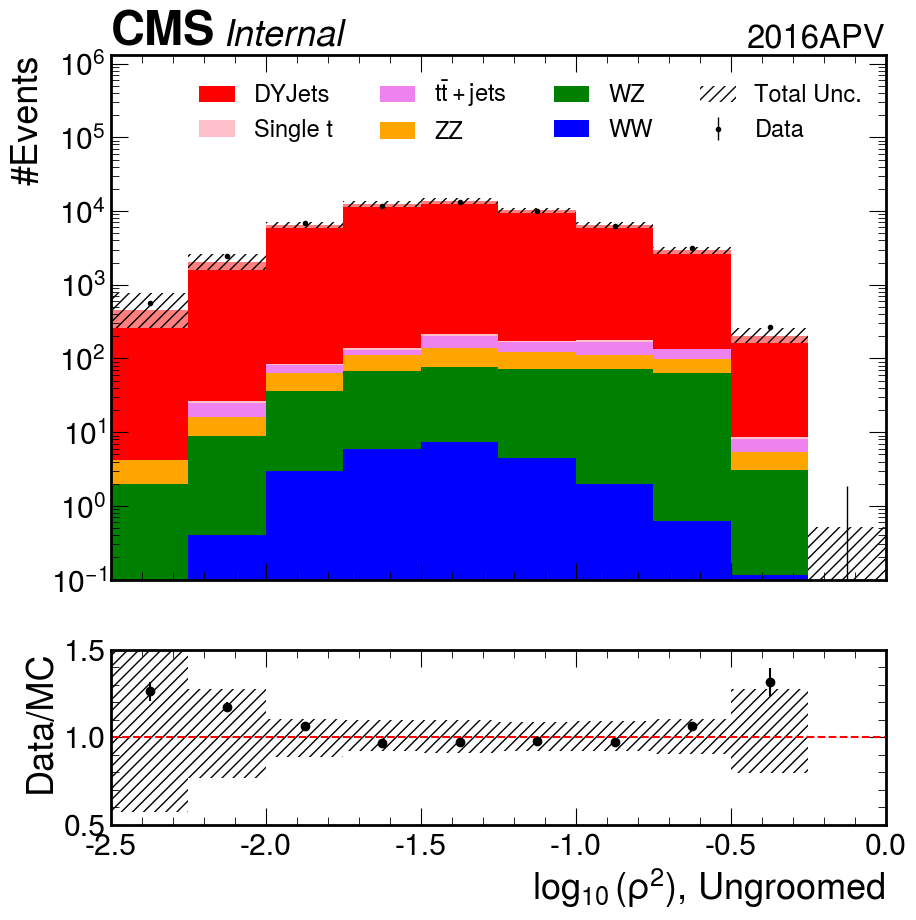

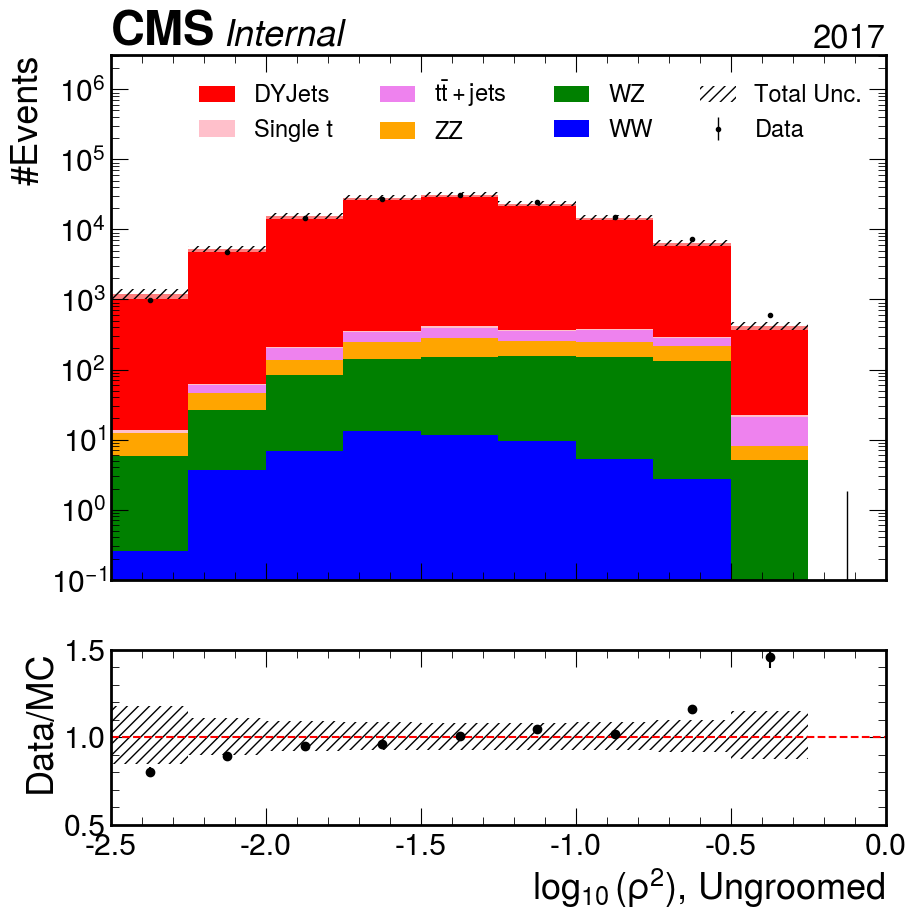

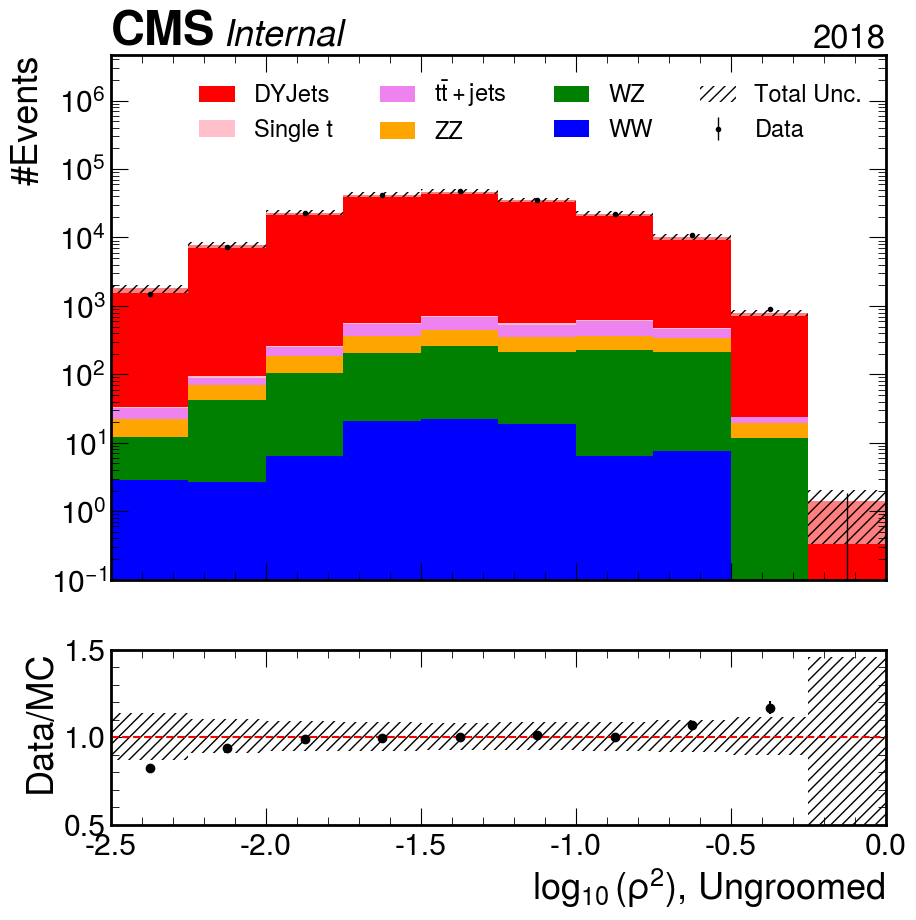

In [16]:
for era in ["2016","2016APV", "2017", "2018"]:
    plot_data_mc( bkg, st, "ptjet_rhojet_u_reco", "mpt_reco", era, file_id = "rho_u", groomed = False, xmin =  -2.5)